# R4 - Verificación de entradas para segmentación

Este notebook verifica que las entradas utilizadas por el pipeline de segmentación se encuentren correctamente organizadas, emparejadas y preparadas antes de ejecutar el entrenamiento del modelo U-Net baseline.

> **Alcance:** Su función es exclusivamente de verificación y trazabilidad de las entradas de R4.

## 1. Configuración del entorno

In [6]:
from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader
from IPython.display import display


SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 4

SPLITS = (
    "train",
    "validation",
    "test"
)


def locate_project_root() -> Path:
    current_dir = Path.cwd().resolve()

    candidates = [current_dir, *current_dir.parents]

    for candidate in candidates:
        dataset_dir = (
            candidate
            / "data"
            / "processed"
            / "MMOTU_OTU_2D_experimental"
        )

        src_dir = candidate / "src"

        if dataset_dir.exists() and src_dir.exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto."
    )


PROJECT_ROOT = locate_project_root()

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "MMOTU_OTU_2D_experimental"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "notebooks"
    / "R4_segmentation"
    / "reports"
    / "01_verificacion_entrada"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SPLIT_DIRS = {
    split: {
        "images": DATASET_DIR / split / "images",
        "masks": DATASET_DIR / split / "masks",
    }
    for split in SPLITS
}


if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nDataset experimental:")
print(DATASET_DIR)

print("\nDirectorio de reportes:")
print(OUTPUT_DIR)

print("\nPyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Raíz del proyecto:
/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification

Dataset experimental:
/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/data/processed/MMOTU_OTU_2D_experimental

Directorio de reportes:
/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/notebooks/R4_segmentation/reports/01_verificacion_entrada

PyTorch: 2.5.1+cu121
CUDA disponible: True
GPU: NVIDIA GeForce RTX 3080


## 2. Verificación mínima de estructura de entrada

In [7]:
structure_records = []

for split in SPLITS:
    for kind in ("images", "masks"):
        path = SPLIT_DIRS[split][kind]

        structure_records.append(
            {
                "split": split,
                "tipo": kind,
                "ruta": str(path),
                "existe": path.exists(),
            }
        )

structure_df = pd.DataFrame(structure_records)

display(structure_df)

if not structure_df["existe"].all():
    missing = structure_df.loc[
        ~structure_df["existe"],
        ["split", "tipo", "ruta"]
    ]

    raise FileNotFoundError(
        "Faltan directorios requeridos:\n"
        + missing.to_string(index=False)
    )

print("Estructura física: OK")

,split,tipo,ruta,existe
0,train,images,/home/jvillanueva/projects/ovarian-tumor-ultra...,True
1,train,masks,/home/jvillanueva/projects/ovarian-tumor-ultra...,True
2,validation,images,/home/jvillanueva/projects/ovarian-tumor-ultra...,True
3,validation,masks,/home/jvillanueva/projects/ovarian-tumor-ultra...,True
4,test,images,/home/jvillanueva/projects/ovarian-tumor-ultra...,True
5,test,masks,/home/jvillanueva/projects/ovarian-tumor-ultra...,True


Estructura física: OK


In [8]:
from src.segmentation.dataset import (
    get_files_by_id,
    OvarianTumorSegmentationDataset,
)


indexed_data = {}
pairing_records = []

for split in SPLITS:
    images = get_files_by_id(
        SPLIT_DIRS[split]["images"],
        is_mask=False,
    )

    masks = get_files_by_id(
        SPLIT_DIRS[split]["masks"],
        is_mask=True,
    )

    image_ids = set(images)
    mask_ids = set(masks)

    missing_masks = image_ids - mask_ids
    missing_images = mask_ids - image_ids

    indexed_data[split] = {
        "images": images,
        "masks": masks,
    }

    pairing_records.append(
        {
            "split": split,
            "imagenes": len(images),
            "mascaras": len(masks),
            "imagenes_sin_mascara": len(missing_masks),
            "mascaras_sin_imagen": len(missing_images),
            "correspondencia_100_pct": (
                len(missing_masks) == 0
                and len(missing_images) == 0
            ),
        }
    )

pairing_df = pd.DataFrame(pairing_records)

display(pairing_df)

if not pairing_df["correspondencia_100_pct"].all():
    raise ValueError(
        "Se detectaron inconsistencias imagen-máscara. "
        "Revise la tabla anterior antes de continuar."
    )

print("Correspondencia imagen-máscara: OK")

,split,imagenes,mascaras,imagenes_sin_mascara,mascaras_sin_imagen,correspondencia_100_pct
0,train,800,800,0,0,True
1,validation,200,200,0,0,True
2,test,469,469,0,0,True


Correspondencia imagen-máscara: OK


### Ejemplos de emparejamiento

Se muestran algunos IDs para comprobar visualmente que la convención de nombres se interpreta correctamente.

In [9]:
for split in SPLITS:
    print(f"\n{split.upper()}")

    ids = sorted(
        indexed_data[split]["images"].keys(),
        key=int,
    )

    for image_id in ids[:5]:
        print(
            image_id,
            "->",
            indexed_data[split]["images"][image_id].name,
            "<->",
            indexed_data[split]["masks"][image_id].name,
        )


TRAIN
1 -> 1.JPG <-> 1_binary.PNG
2 -> 2.JPG <-> 2_binary.PNG
4 -> 4.JPG <-> 4_binary.PNG
7 -> 7.JPG <-> 7_binary.PNG
9 -> 9.JPG <-> 9_binary.PNG

VALIDATION
6 -> 6.JPG <-> 6_binary.PNG
11 -> 11.JPG <-> 11_binary.PNG
13 -> 13.JPG <-> 13_binary.PNG
17 -> 17.JPG <-> 17_binary.PNG
19 -> 19.JPG <-> 19_binary.PNG

TEST
3 -> 3.JPG <-> 3_binary.PNG
5 -> 5.JPG <-> 5_binary.PNG
8 -> 8.JPG <-> 8_binary.PNG
12 -> 12.JPG <-> 12_binary.PNG
15 -> 15.JPG <-> 15_binary.PNG


## 4. Verificación de máscaras para segmentación

El `Dataset` de segmentación espera máscaras binarias con valores `{0, 1}`.

Una máscara vacía no implica necesariamente un error de archivo, pero debe quedar identificada porque puede afectar la interpretación de Dice e IoU.

In [10]:
def analyze_masks(mask_paths):
    unique_values = set()
    empty_masks = 0
    foreground_fractions = []

    for mask_path in mask_paths:
        with Image.open(mask_path) as mask:
            mask_array = np.asarray(mask.convert("L"))

        unique_values.update(
            np.unique(mask_array).tolist()
        )

        foreground = mask_array > 0
        foreground_pixels = int(foreground.sum())

        if foreground_pixels == 0:
            empty_masks += 1

        foreground_fractions.append(
            foreground_pixels / foreground.size
        )

    return {
        "unique_values": sorted(unique_values),
        "empty_masks": empty_masks,
        "foreground_fraction_mean": float(
            np.mean(foreground_fractions)
        ),
        "foreground_fraction_median": float(
            np.median(foreground_fractions)
        ),
        "foreground_fraction_min": float(
            np.min(foreground_fractions)
        ),
        "foreground_fraction_max": float(
            np.max(foreground_fractions)
        ),
    }


mask_records = []

for split in SPLITS:
    analysis = analyze_masks(
        list(indexed_data[split]["masks"].values())
    )

    mask_records.append(
        {
            "split": split,
            **analysis,
        }
    )

mask_df = pd.DataFrame(mask_records)

display(mask_df)

all_mask_values = set()

for values in mask_df["unique_values"]:
    all_mask_values.update(values)

if not all_mask_values.issubset({0, 1}):
    raise ValueError(
        "Las máscaras no están codificadas exclusivamente como {0, 1}. "
        f"Valores encontrados: {sorted(all_mask_values)}. "
        "No continúe con el entrenamiento hasta revisar la codificación "
        "o adaptar explícitamente src/segmentation/dataset.py."
    )

print("Codificación binaria de máscaras: OK")

,split,unique_values,empty_masks,foreground_fraction_mean,foreground_fraction_median,foreground_fraction_min,foreground_fraction_max
0,train,"[0, 1]",0,0.144839,0.117571,0.005687,0.617562
1,validation,"[0, 1]",0,0.144581,0.108286,0.005415,0.522245
2,test,"[0, 1]",0,0.149010,0.124687,0.003148,0.599707


Codificación binaria de máscaras: OK


## 4. Validación del Dataset PyTorch
Se crean los tres objetos `OvarianTumorSegmentationDataset` empleando la implementación oficial del proyecto.

In [11]:
datasets = {}

for split in SPLITS:
    datasets[split] = OvarianTumorSegmentationDataset(
        images_dir=SPLIT_DIRS[split]["images"],
        masks_dir=SPLIT_DIRS[split]["masks"],
        image_size=IMAGE_SIZE,
    )

    print(
        f"{split}: {len(datasets[split])} muestras"
    )


dataset_validation_records = []

for split in SPLITS:
    sample = datasets[split][0]

    image = sample["image"]
    mask = sample["mask"]

    valid = (
        tuple(image.shape) == (3, *IMAGE_SIZE)
        and tuple(mask.shape) == (1, *IMAGE_SIZE)
        and image.dtype == torch.float32
        and mask.dtype == torch.float32
        and image.min().item() >= 0.0
        and image.max().item() <= 1.0
        and set(
            torch.unique(mask).cpu().numpy().tolist()
        ).issubset({0.0, 1.0})
    )

    dataset_validation_records.append(
        {
            "split": split,
            "image_id": sample["image_id"],
            "image_shape": tuple(image.shape),
            "mask_shape": tuple(mask.shape),
            "image_dtype": str(image.dtype),
            "mask_dtype": str(mask.dtype),
            "image_min": float(image.min()),
            "image_max": float(image.max()),
            "mask_values": (
                torch.unique(mask)
                .cpu()
                .numpy()
                .tolist()
            ),
            "valido": valid,
        }
    )

dataset_validation_df = pd.DataFrame(
    dataset_validation_records
)

display(dataset_validation_df)

if not dataset_validation_df["valido"].all():
    raise ValueError(
        "La validación del Dataset falló en al menos "
        "una partición."
    )

print("Dataset PyTorch: OK")

train: 800 muestras
validation: 200 muestras
test: 469 muestras


,split,image_id,image_shape,mask_shape,image_dtype,mask_dtype,image_min,image_max,mask_values,valido
0,train,1,"(3, 256, 256)","(1, 256, 256)",torch.float32,torch.float32,0.0,0.988235,"[0.0, 1.0]",True
1,validation,6,"(3, 256, 256)","(1, 256, 256)",torch.float32,torch.float32,0.0,0.996078,"[0.0, 1.0]",True
2,test,3,"(3, 256, 256)","(1, 256, 256)",torch.float32,torch.float32,0.0,0.996078,"[0.0, 1.0]",True


Dataset PyTorch: OK


## 5. Inspección visual de entradas

Se visualiza una muestra por partición junto con su máscara de referencia. Esta inspección es complementaria a las verificaciones automáticas y permite detectar problemas visibles de orientación, redimensionamiento o correspondencia.

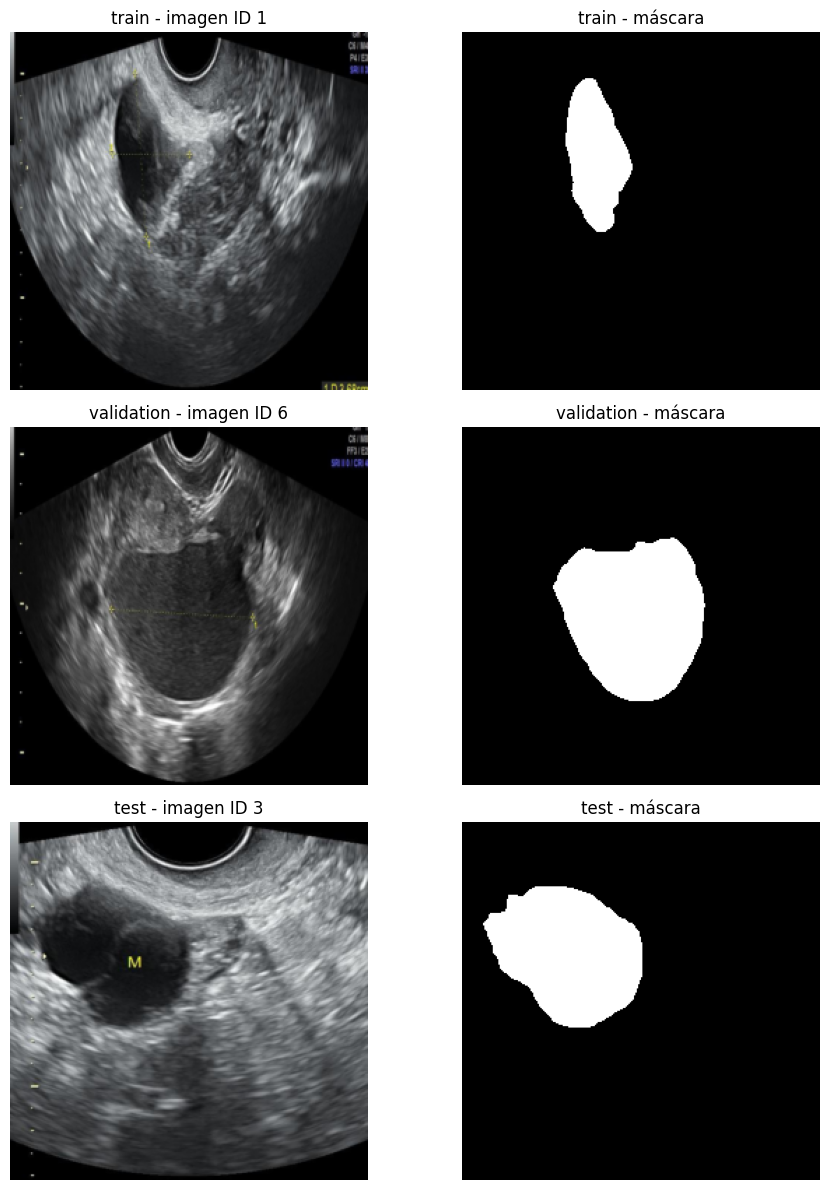

In [12]:
fig, axes = plt.subplots(
    len(SPLITS),
    2,
    figsize=(10, 4 * len(SPLITS)),
)

for row, split in enumerate(SPLITS):
    sample = datasets[split][0]

    image = (
        sample["image"]
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    mask = (
        sample["mask"][0]
        .cpu()
        .numpy()
    )

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"{split} - imagen ID {sample['image_id']}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title(
        f"{split} - máscara"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 10. Validación de los `DataLoader`

Se crean los cargadores de datos que servirán de base para el entrenamiento y evaluación del segmentador.

In [13]:
generator = torch.Generator()
generator.manual_seed(SEED)

loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=generator,
    ),
    "validation": DataLoader(
        datasets["validation"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    ),
}


loader_records = []

for split in SPLITS:
    batch = next(iter(loaders[split]))

    images = batch["image"]
    masks = batch["mask"]

    loader_records.append(
        {
            "split": split,
            "n_batches": len(loaders[split]),
            "batch_images_shape": tuple(images.shape),
            "batch_masks_shape": tuple(masks.shape),
            "images_dtype": str(images.dtype),
            "masks_dtype": str(masks.dtype),
            "mask_values": (
                torch.unique(masks)
                .cpu()
                .numpy()
                .tolist()
            ),
        }
    )

loader_df = pd.DataFrame(loader_records)

display(loader_df)

print("DataLoaders: OK")

,split,n_batches,batch_images_shape,batch_masks_shape,images_dtype,masks_dtype,mask_values
0,train,200,"(4, 3, 256, 256)","(4, 1, 256, 256)",torch.float32,torch.float32,"[0.0, 1.0]"
1,validation,50,"(4, 3, 256, 256)","(4, 1, 256, 256)",torch.float32,torch.float32,"[0.0, 1.0]"
2,test,118,"(4, 3, 256, 256)","(4, 1, 256, 256)",torch.float32,torch.float32,"[0.0, 1.0]"


DataLoaders: OK


## 7. Resumen de verificaciones

In [16]:
structure_ok = structure_df["existe"].all()

pairing_ok = pairing_df[
    "correspondencia_100_pct"
].all()

mask_binary_ok = all_mask_values.issubset({0, 1})

dataset_ok = dataset_validation_df[
    "valido"
].all()

loader_ok = len(loader_df) == len(SPLITS)

total_empty_masks = int(
    mask_df["empty_masks"].sum()
)


summary_records = [
    {
        "verificacion": "Estructura de entrada",
        "resultado": (
            "Completa"
            if structure_ok
            else "Incompleta"
        ),
        "estado": (
            "Cumplido"
            if structure_ok
            else "Revisar"
        ),
    },
    {
        "verificacion": "Correspondencia imagen-máscara",
        "resultado": (
            "100 %"
            if pairing_ok
            else "Con inconsistencias"
        ),
        "estado": (
            "Cumplido"
            if pairing_ok
            else "Revisar"
        ),
    },
    {
        "verificacion": "Máscaras binarias {0,1}",
        "resultado": (
            "Sí"
            if mask_binary_ok
            else "No"
        ),
        "estado": (
            "Cumplido"
            if mask_binary_ok
            else "Revisar"
        ),
    },
    {
        "verificacion": "Máscaras vacías",
        "resultado": str(total_empty_masks),
        "estado": (
            "Cumplido"
            if total_empty_masks == 0
            else "Documentar"
        ),
    },
    {
        "verificacion": "Dataset PyTorch",
        "resultado": (
            "Correcto"
            if dataset_ok
            else "Incorrecto"
        ),
        "estado": (
            "Cumplido"
            if dataset_ok
            else "Revisar"
        ),
    },
    {
        "verificacion": "DataLoaders",
        "resultado": (
            "Operativos"
            if loader_ok
            else "Incompletos"
        ),
        "estado": (
            "Cumplido"
            if loader_ok
            else "Revisar"
        ),
    },
]


summary_df = pd.DataFrame(summary_records)

display(summary_df)

,verificacion,resultado,estado
0,Estructura de entrada,Completa,Cumplido
1,Correspondencia imagen-máscara,100 %,Cumplido
2,"Máscaras binarias {0,1}",Sí,Cumplido
3,Máscaras vacías,0,Cumplido
4,Dataset PyTorch,Correcto,Cumplido
5,DataLoaders,Operativos,Cumplido


In [17]:
# Guardado de reportes

mask_df.to_csv(
    OUTPUT_DIR / "mask_analysis.csv",
    index=False,
    encoding="utf-8-sig",
)

summary_df.to_csv(
    OUTPUT_DIR / "verification_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Reportes guardados en:")
print(OUTPUT_DIR)

Reportes guardados en:
/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/notebooks/R4_segmentation/reports/01_verificacion_entrada
